# Chapter 1 — Matrix computations, orthogonality, and norms

**Numerical Linear Algebra: Theory, Algorithms, and Computation**

**Abdallah Alsammani, Ph.D.**  
Department of Mathematical Sciences & Data Science  
Delaware State University

Lecture notes: <https://aalsammani.github.io/numerical-linear-algebra/>  
Notes for this chapter: <https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html>  
Repository: <https://github.com/aalsammani/Numerical-Linear-Algebra-Notebooks>

This notebook is the computational laboratory of the chapter; the theory,
proofs and exercises are in the lecture notes, to which the links below
point. References such as Trefethen and Bau (1997) are listed in the
[bibliography of the notes](https://aalsammani.github.io/numerical-linear-algebra/back/bibliography.html). Version
1.0, September 2026.

---

This notebook accompanies [Chapter 1](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01) of the notes. Every
experiment checks a statement from the chapter numerically.

**Learning objectives.** After working through this lab you should be able to

1. implement the inner-product, column and outer-product forms of the matrix
   product and verify them against `A @ B` with a justified tolerance;
2. measure run times carefully and distinguish flop counts from observed speed;
3. construct Householder reflectors and Givens rotations and explain the
   role of the sign choice and of `hypot`;
4. compute vector and matrix norms, and check the inequalities that relate
   them;
5. explain why sampling random unit vectors underestimates $\|A\|_2$.

Run the cells in order from a fresh kernel.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as sla

rng = np.random.default_rng(20260927)
u = np.finfo(float).eps / 2          # unit roundoff of IEEE double precision, 2**-53
plt.rcParams.update({"figure.figsize": (6.4, 4.0), "axes.grid": True, "grid.alpha": 0.3})
print(f"NumPy {np.__version__}; unit roundoff u = {u:.3e}")

NumPy 2.5.3; unit roundoff u = 1.110e-16


## 1. Three ways to multiply matrices

The entry $c_{ij}$ of $C = AB$ is an inner product of a row of $A$ and a
column of $B$; column $j$ of $C$ is $Ab_j$, a combination of the columns of
$A$; and $C$ is the sum of the $k$ outer products $a_\ell\tilde b_\ell^T$
(equations [(1.1)](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#equation-ch01-eq-product)--[(1.3)](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#equation-ch01-eq-outer-view)). The three
functions below implement these views literally.

In [2]:
def matmul_inner(A, B):
    """C[i, j] = (row i of A) . (column j of B): a triple loop."""
    m, k = A.shape
    k2, n = B.shape
    assert k == k2, "inner dimensions must agree"
    C = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            s = 0.0
            for ell in range(k):
                s += A[i, ell] * B[ell, j]
            C[i, j] = s
    return C


def matmul_column(A, B):
    """Column j of C is A @ b_j, a linear combination of the columns of A."""
    C = np.zeros((A.shape[0], B.shape[1]))
    for j in range(B.shape[1]):
        for ell in range(A.shape[1]):
            C[:, j] += B[ell, j] * A[:, ell]
    return C


def matmul_outer(A, B):
    """C is the sum of the rank-one matrices a_ell (row ell of B)."""
    C = np.zeros((A.shape[0], B.shape[1]))
    for ell in range(A.shape[1]):
        C += np.outer(A[:, ell], B[ell, :])
    return C

**How close should the results be?** The three functions perform the same
multiplications but add them in different orders, so their results differ
by rounding errors. A standard bound (proved in [Chapter 3](https://aalsammani.github.io/numerical-linear-algebra/ch03-floating-point/notes.html#ch03))
says that any order of summation gives a computed product $\widehat C$ with
$|\widehat C - AB| \le \gamma_k |A|\,|B|$ entrywise, where
$\gamma_k = ku/(1-ku)$ and $|A|$ is the matrix of absolute values. Two
computed products can therefore differ by at most $2\gamma_k|A||B|$. We test
exactly this bound rather than an arbitrary tolerance.

In [3]:
m, k, n = 30, 40, 20
A = rng.standard_normal((m, k))
B = rng.standard_normal((k, n))
C_ref = A @ B
gamma_k = k * u / (1 - k * u)
bound = 2 * gamma_k * (np.abs(A) @ np.abs(B))

for f in (matmul_inner, matmul_column, matmul_outer):
    C = f(A, B)
    ratio = np.max(np.abs(C - C_ref) / bound)
    print(f"{f.__name__:14s} max |C - C_ref| = {np.max(np.abs(C - C_ref)):.2e}; "
          f"fraction of the bound used = {ratio:.3f}")
    assert np.all(np.abs(C - C_ref) <= bound)

matmul_inner   max |C - C_ref| = 7.11e-15; fraction of the bound used = 0.026
matmul_column  max |C - C_ref| = 7.11e-15; fraction of the bound used = 0.026
matmul_outer   max |C - C_ref| = 7.11e-15; fraction of the bound used = 0.026


The observed differences use only a small fraction of the worst-case bound,
which is typical: rounding errors tend to partially cancel. The
bound is nevertheless the right test, because it is guaranteed.

The worked example of the notes ([Example 1.1](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-exa-three-views)) can be
checked exactly, since all its entries are small integers.

In [4]:
A_ex = np.array([[1.0, 2.0], [0.0, 1.0], [3.0, 0.0]])
B_ex = np.array([[2.0, -1.0], [1.0, 4.0]])
print(matmul_outer(A_ex, B_ex))
assert np.array_equal(matmul_outer(A_ex, B_ex), np.array([[4.0, 7.0], [1.0, 4.0], [6.0, -3.0]]))

[[ 4.  7.]
 [ 1.  4.]
 [ 6. -3.]]


## 2. Flops versus run time

All three loops and `A @ B` perform $2n^3$ flops for square matrices, up to
lower-order terms ([Proposition 1.2](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-prop-flops)). We now time them. To make timings meaningful
we repeat each measurement and report the median, after one warm-up call.
The absolute numbers depend on the machine, the BLAS library and the Python
interpreter that executed this notebook; the slopes on a log-log plot are
what the flop count predicts.

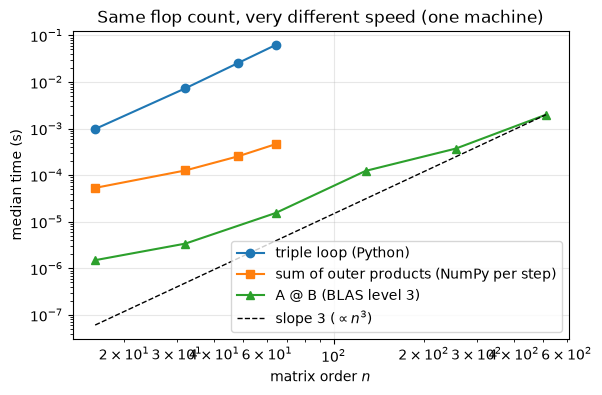

Observed rate of A @ B at n = 512: 134.8 Gflop/s
Observed rate of the Python loop at n = 64: 8.44 Mflop/s


In [5]:
def median_time(f, *args, repeats=5):
    f(*args)                               # warm-up
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        f(*args)
        times.append(time.perf_counter() - t0)
    return float(np.median(times))


sizes_loop = [16, 32, 48, 64]
sizes_blas = [16, 32, 64, 128, 256, 512]
t_inner = [median_time(matmul_inner, *(rng.standard_normal((n, n)) for _ in range(2)), repeats=3)
           for n in sizes_loop]
t_outer = [median_time(matmul_outer, *(rng.standard_normal((n, n)) for _ in range(2)))
           for n in sizes_loop]
t_blas = [median_time(np.matmul, *(rng.standard_normal((n, n)) for _ in range(2)), repeats=20)
          for n in sizes_blas]

fig, ax = plt.subplots()
ax.loglog(sizes_loop, t_inner, "o-", label="triple loop (Python)")
ax.loglog(sizes_loop, t_outer, "s-", label="sum of outer products (NumPy per step)")
ax.loglog(sizes_blas, t_blas, "^-", label="A @ B (BLAS level 3)")
ref = np.array(sizes_blas, dtype=float)
ax.loglog(ref, t_blas[-1] * (ref / ref[-1]) ** 3, "k--", lw=1, label=r"slope 3 ($\propto n^3$)")
ax.set_xlabel("matrix order $n$")
ax.set_ylabel("median time (s)")
ax.set_title("Same flop count, very different speed (one machine)")
ax.legend()
plt.show()

n_big = sizes_blas[-1]
print(f"Observed rate of A @ B at n = {n_big}: {2 * n_big**3 / t_blas[-1] / 1e9:.1f} Gflop/s")
print(f"Observed rate of the Python loop at n = {sizes_loop[-1]}: "
      f"{2 * sizes_loop[-1]**3 / t_inner[-1] / 1e6:.2f} Mflop/s")

**Interpretation.** The Python loop spends its time interpreting bytecode,
so its rate is millions of flops per second. `A @ B` calls an optimized BLAS
routine that keeps blocks of the matrices in cache and uses vector
instructions and several cores, and reaches billions of flops per second. For
small $n$ the BLAS curve is flat because fixed overheads dominate; the
$n^3$ behavior is visible only for larger $n$. None of these numbers is a
property of the algorithms, which all perform the same arithmetic.

**Order of evaluation.** The cost of a product chain depends on where the
parentheses go ([Exercise 1.2](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-ex-chain)): $(AB)x$ costs about $2n^3$ flops and
$A(Bx)$ about $4n^2$.

In [6]:
n = 1000
A = rng.standard_normal((n, n))
B = rng.standard_normal((n, n))
x = rng.standard_normal(n)
t_left = median_time(lambda: (A @ B) @ x)
t_right = median_time(lambda: A @ (B @ x))
print(f"(AB)x: {t_left * 1e3:.2f} ms   A(Bx): {t_right * 1e3:.3f} ms   ratio {t_left / t_right:.0f}")
print(f"flop ratio predicted: {(2 * n**3 + 2 * n**2) / (4 * n**2):.0f}")
# Both orders compute the same vector up to rounding: |difference| <= 2 gamma_{2n} |A||B||x|.
gamma_2n = 2 * n * u / (1 - 2 * n * u)
assert np.all(np.abs((A @ B) @ x - A @ (B @ x)) <= 2 * gamma_2n * (np.abs(A) @ (np.abs(B) @ np.abs(x))))

(AB)x: 13.83 ms   A(Bx): 0.523 ms   ratio 26
flop ratio predicted: 500


The measured ratio is usually smaller than the flop ratio, because
matrix-vector products run at the lower speed of level-2 BLAS: they are
limited by memory traffic rather than arithmetic.

## 3. Orthogonal matrices

A convenient source of random orthogonal matrices is the $Q$ factor of the QR
factorization of a Gaussian matrix ([Chapter 7](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07)). We check the
properties in [Proposition 1.3](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-prop-orthogonal). A computed $Q$ is orthogonal
only to within rounding errors; for Householder QR the departure
$\|Q^TQ - I\|_2$ is a modest multiple of $nu$, and we test against $10nu$.

In [7]:
n = 200
Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
x = rng.standard_normal(n)
y = rng.standard_normal(n)
lam = np.linalg.eigvals(Q)

orth_err = np.linalg.norm(Q.T @ Q - np.eye(n), 2)
print(f"||Q^T Q - I||_2          = {orth_err:.2e}   (n u = {n * u:.2e})")
print(f"| ||Qx|| / ||x|| - 1 |    = {abs(np.linalg.norm(Q @ x) / np.linalg.norm(x) - 1):.2e}")
print(f"|(Qx)^T(Qy) - x^T y|      = {abs((Q @ x) @ (Q @ y) - x @ y):.2e}")
print(f"max | |lambda| - 1 |      = {np.max(np.abs(np.abs(lam) - 1)):.2e}")
print(f"det(Q)                    = {np.linalg.det(Q):+.12f}")
assert orth_err < 10 * n * u
assert abs(abs(np.linalg.det(Q)) - 1) < 10 * n * u

||Q^T Q - I||_2          = 2.33e-15   (n u = 2.22e-14)
| ||Qx|| / ||x|| - 1 |    = 1.11e-16
|(Qx)^T(Qy) - x^T y|      = 1.07e-14
max | |lambda| - 1 |      = 1.07e-14
det(Q)                    = -1.000000000000


A rectangular matrix with orthonormal columns satisfies $Q^TQ = I_n$ but not
$QQ^T = I_m$; $QQ^T$ is a projector of rank $n$.

In [8]:
Q_thin, _ = np.linalg.qr(rng.standard_normal((6, 2)))
P = Q_thin @ Q_thin.T
print(f"||Q^T Q - I_2|| = {np.linalg.norm(Q_thin.T @ Q_thin - np.eye(2)):.1e}")
print(f"||Q Q^T - I_6|| = {np.linalg.norm(P - np.eye(6)):.3f}")
print(f"P^2 = P: {np.allclose(P @ P, P)};  rank(P) = {np.linalg.matrix_rank(P)}")

||Q^T Q - I_2|| = 8.5e-17
||Q Q^T - I_6|| = 2.000
P^2 = P: True;  rank(P) = 2


## 4. Householder reflectors

We implement [Algorithm 1.1](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-alg-householder). The function returns $v$ with
$v_1 = 1$ and $\beta = 2/(v^Tv)$, and a second function applies
$H = I - \beta vv^T$ to a vector without forming $H$.

In [9]:
def householder_vector(x):
    """Return (v, beta, alpha) with (I - beta v v^T) x = alpha e_1 and v[0] = 1.

    The sign of alpha is chosen opposite to x[0] (sign(0) = +1) so that
    v[0] = x[0] - alpha is computed without cancellation.
    """
    x = np.asarray(x, dtype=float)
    normx = np.linalg.norm(x)
    if normx == 0:
        raise ValueError("x must be nonzero")
    s = 1.0 if x[0] >= 0 else -1.0
    alpha = -s * normx
    v = x.copy()
    v[0] = x[0] - alpha                    # = x[0] + s*||x||: no cancellation
    v = v / v[0]
    beta = 2.0 / (v @ v)
    return v, beta, alpha


def apply_householder(v, beta, y):
    """Compute (I - beta v v^T) y in about 4m flops."""
    return y - beta * v * (v @ y)

**Verification.** $Hx$ should equal $\alpha e_1$ up to rounding errors of
order $mu\|x\|_2$, and the explicit matrix $H$ should be symmetric and
orthogonal to working accuracy. We also compare with SciPy, whose QR routine
uses the same reflectors internally: the first column of `scipy.linalg.qr`'s
$R$ has entry $\pm\|x\|_2$ at the top.

In [10]:
for m in (2, 10, 500):
    x = rng.standard_normal(m)
    v, beta, alpha = householder_vector(x)
    Hx = apply_householder(v, beta, x)
    target = np.zeros(m); target[0] = alpha
    rel_err = np.linalg.norm(Hx - target) / np.linalg.norm(x)
    H = np.eye(m) - beta * np.outer(v, v)
    orth = np.linalg.norm(H.T @ H - np.eye(m), 2)
    r11 = sla.qr(x.reshape(-1, 1), mode="r")[0][0, 0]
    print(f"m = {m:3d}: ||Hx - alpha e1||/||x|| = {rel_err:.1e}, ||H^T H - I|| = {orth:.1e}, "
          f"|alpha| - |r11 (SciPy)| = {abs(alpha) - abs(r11):.1e}")
    assert rel_err < 10 * m * u and orth < 10 * m * u
    assert abs(abs(alpha) - abs(r11)) < 10 * m * u * abs(alpha)
    assert np.array_equal(H, H.T)
    if m <= 10:                                   # determinant of a reflector is -1
        assert abs(np.linalg.det(H) + 1) < 10 * m * u

m =   2: ||Hx - alpha e1||/||x|| = 0.0e+00, ||H^T H - I|| = 2.7e-16, |alpha| - |r11 (SciPy)| = 0.0e+00
m =  10: ||Hx - alpha e1||/||x|| = 1.9e-16, ||H^T H - I|| = 2.5e-16, |alpha| - |r11 (SciPy)| = -4.4e-16


m = 500: ||Hx - alpha e1||/||x|| = 2.0e-16, ||H^T H - I|| = 8.9e-16, |alpha| - |r11 (SciPy)| = 0.0e+00


**The sign matters.** Now we reverse the sign choice, as in
[Exercise 1.6](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-ex-householder-sign), for vectors $x = (1, t)^T$ that are already
close to $e_1$. With the wrong sign, $v_1 = x_1 - \|x\|_2$ is computed by
subtracting two nearly equal numbers.

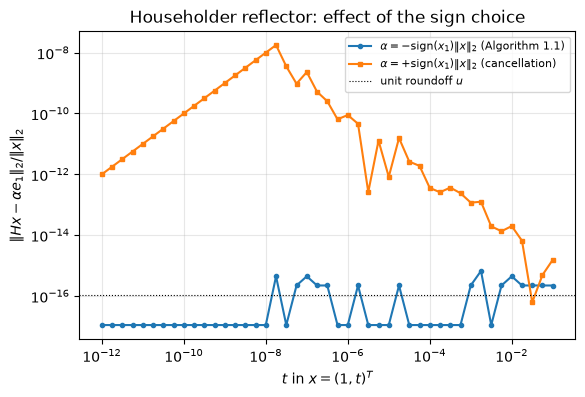

x = (1, 1e-9): good sign error 0.0e+00, wrong sign error 1.0e-09


In [11]:
def householder_wrong_sign(x):
    x = np.asarray(x, dtype=float)
    alpha = np.sign(x[0]) * np.linalg.norm(x)     # same sign as x[0]: cancellation
    v = x.copy()
    v[0] = x[0] - alpha
    return v, alpha


ts = np.logspace(-1, -12, 45)
err_good, err_bad = [], []
for t in ts:
    x = np.array([1.0, t])
    v, beta, alpha = householder_vector(x)
    err_good.append(np.linalg.norm(apply_householder(v, beta, x) - [alpha, 0]) / np.linalg.norm(x))
    vb, ab = householder_wrong_sign(x)
    Hx = x - 2 * vb * (vb @ x) / (vb @ vb)
    err_bad.append(np.linalg.norm(Hx - [ab, 0]) / np.linalg.norm(x))

fig, ax = plt.subplots()
ax.loglog(ts, np.maximum(err_good, u / 10), "o-", ms=3, label=r"$\alpha = -\mathrm{sign}(x_1)\|x\|_2$ (Algorithm 1.1)")
ax.loglog(ts, err_bad, "s-", ms=3, label=r"$\alpha = +\mathrm{sign}(x_1)\|x\|_2$ (cancellation)")
ax.axhline(u, color="k", lw=0.8, ls=":", label="unit roundoff $u$")
ax.set_xlabel(r"$t$ in $x = (1, t)^T$")
ax.set_ylabel(r"$\|Hx - \alpha e_1\|_2 / \|x\|_2$")
ax.set_title("Householder reflector: effect of the sign choice")
ax.legend(fontsize=8)
plt.show()
print(f"x = (1, 1e-9): good sign error {err_good[np.argmin(abs(ts - 1e-9))]:.1e}, "
      f"wrong sign error {err_bad[np.argmin(abs(ts - 1e-9))]:.1e}")

With the correct sign the error stays at the level of $u$; for many $t$ it
is exactly zero, and those points are drawn at $u/10$ so that they appear on
the logarithmic axis. With the wrong
sign it grows as $t$ decreases, and once $t^2<u$ the computed $\|x\|_2$ equals
$1$ exactly, $v_1$ becomes $0$, and the reflector maps $x$ to $(1,-t)^T$: the
relative error is then $t$ itself.

## 5. Givens rotations and `hypot`

A rotation that zeros $x_j$ against $x_i$ uses $c = x_i/r$, $s = x_j/r$ with
$r = \sqrt{x_i^2 + x_j^2}$. Computing $r$ naively can overflow or underflow
even when $r$ itself is a perfectly representable number.

In [12]:
def givens(a, b):
    """Return (c, s, r) with [[c, s], [-s, c]] @ [a, b] = [r, 0]."""
    if b == 0.0:
        return 1.0, 0.0, a
    r = np.hypot(a, b)                      # scaled internally: no overflow
    return a / r, b / r, r


for a, b in [(3.0, 4.0), (1e200, 1e200), (1e-200, 3e-200)]:
    c, s, r = givens(a, b)
    G = np.array([[c, s], [-s, c]])
    with np.errstate(over="ignore", under="ignore"):
        naive = np.sqrt(a * a + b * b)
    print(f"(a, b) = ({a:.0e}, {b:.0e}): G @ (a, b) = {G @ np.array([a, b])}, naive r = {naive:.3e}, hypot r = {r:.3e}")
    assert abs((G @ np.array([a, b]))[1]) <= 4 * u * abs(r)
    c_ref, s_ref, r_ref = sla.lapack.dlartg(a, b)       # LAPACK's Givens rotation, for comparison
    assert max(abs(c - c_ref), abs(s - s_ref)) <= 4 * u and abs(r - r_ref) <= 4 * u * abs(r)

(a, b) = (3e+00, 4e+00): G @ (a, b) = [ 5.00000000e+00 -2.22044605e-16], naive r = 5.000e+00, hypot r = 5.000e+00
(a, b) = (1e+200, 1e+200): G @ (a, b) = [ 1.41421356e+200 -3.86166634e+182], naive r = inf, hypot r = 1.414e+200
(a, b) = (1e-200, 3e-200): G @ (a, b) = [3.16227766e-200 5.32779048e-217], naive r = 0.000e+00, hypot r = 3.162e-200


The naive formula returns `inf` for $a = b = 10^{200}$ (because $a^2$
overflows) and a wrong answer for $a, b \approx 10^{-200}$ (because $a^2$
underflows to zero or to a subnormal number), while `hypot` is accurate in
both cases. Our rotations agree with LAPACK's `dlartg` (called through
`scipy.linalg.lapack`) to within a few units of $u$.

## 6. Vector norms

We reproduce [Example 1.2](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-exa-vector-norms) and test the inequalities of
[Theorem 1.3](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-thm-norm-equivalence) on many random vectors, including the
vectors that attain the constants.

In [13]:
x = np.array([3.0, -4.0, 0.0, 12.0])
print([np.linalg.norm(x, p) for p in (1, 2, np.inf)])
assert [np.linalg.norm(x, p) for p in (1, 2, np.inf)] == [19.0, 13.0, 12.0]

n = 50
X = rng.standard_normal((n, 2000)) * rng.exponential(size=(1, 2000))
X = np.hstack([X, np.eye(n)[:, :1], np.ones((n, 1))])        # e_1 and the ones vector attain the bounds
n1, n2, ninf = (np.linalg.norm(X, p, axis=0) for p in (1, 2, np.inf))
tol = 1 + 4 * n * u                                          # allow rounding in the computed norms
checks = {
    "||x||_inf <= ||x||_2":        np.all(ninf <= n2 * tol),
    "||x||_2 <= sqrt(n)||x||_inf": np.all(n2 <= np.sqrt(n) * ninf * tol),
    "||x||_2 <= ||x||_1":          np.all(n2 <= n1 * tol),
    "||x||_1 <= sqrt(n)||x||_2":   np.all(n1 <= np.sqrt(n) * n2 * tol),
    "||x||_1 <= n ||x||_inf":      np.all(n1 <= n * ninf * tol),
}
for name, ok in checks.items():
    print(f"{name:30s} {ok}")
assert all(checks.values())
print("ratio ||x||_1 / (sqrt(n)||x||_2) for the ones vector:", n1[-1] / (np.sqrt(n) * n2[-1]))

[np.float64(19.0), np.float64(13.0), np.float64(12.0)]
||x||_inf <= ||x||_2           True
||x||_2 <= sqrt(n)||x||_inf    True
||x||_2 <= ||x||_1             True
||x||_1 <= sqrt(n)||x||_2      True
||x||_1 <= n ||x||_inf         True
ratio ||x||_1 / (sqrt(n)||x||_2) for the ones vector: 0.9999999999999999


## 7. Matrix norms

We implement the three formulas of [Theorem 1.4](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-thm-induced-formulas) and
compare with `numpy.linalg.norm`. Our 2-norm uses the eigenvalues of $A^TA$,
exactly as in the proof. (This is fine for the *largest* singular value; in
[Chapter 2](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#ch02) we will see why forming $A^TA$ is a bad idea for
the small ones.)

In [14]:
def norm_1(A):
    return np.max(np.sum(np.abs(A), axis=0))      # maximum absolute column sum


def norm_inf(A):
    return np.max(np.sum(np.abs(A), axis=1))      # maximum absolute row sum


def norm_2(A):
    return np.sqrt(np.max(np.linalg.eigvalsh(A.T @ A)))


B = np.array([[3.0, 0.0], [4.0, 5.0]])
print(f"B: ||B||_1 = {norm_1(B)}, ||B||_inf = {norm_inf(B)}, ||B||_2 = {norm_2(B):.6f} (3*sqrt(5) = {3 * np.sqrt(5):.6f})")
assert norm_1(B) == 7 and norm_inf(B) == 9
assert abs(norm_2(B) - 3 * np.sqrt(5)) < 10 * u * 3 * np.sqrt(5)   # relative error of order u

for shape in [(5, 5), (40, 7), (7, 40)]:
    A = rng.standard_normal(shape)
    for mine, p in [(norm_1, 1), (norm_inf, np.inf), (norm_2, 2)]:
        ref = np.linalg.norm(A, p)
        assert abs(mine(A) - ref) <= 20 * max(shape) * u * ref, (shape, p)
print("norm formulas agree with numpy.linalg.norm")

B: ||B||_1 = 7.0, ||B||_inf = 9.0, ||B||_2 = 6.708204 (3*sqrt(5) = 6.708204)
norm formulas agree with numpy.linalg.norm


The maximizing vector for the 1-norm is a coordinate vector, and for the
2-norm it is the top eigenvector of $A^TA$. We check that these vectors attain
the norm.

In [15]:
A = rng.standard_normal((6, 4))
k = np.argmax(np.sum(np.abs(A), axis=0))
w, V = np.linalg.eigh(A.T @ A)
v1 = V[:, -1]
gap_1 = abs(np.linalg.norm(A[:, k], 1) - norm_1(A)) / norm_1(A)
gap_2 = abs(np.linalg.norm(A @ v1) - norm_2(A)) / norm_2(A)
print(f"1-norm attained at e_k: relative gap {gap_1:.1e}")
print(f"2-norm attained at v_1: relative gap {gap_2:.1e}")
# Both sides are the same quantity computed by different roundings: relative gap O(m u).
assert gap_1 <= 10 * A.shape[0] * u and gap_2 <= 10 * A.shape[0] * u

1-norm attained at e_k: relative gap 0.0e+00
2-norm attained at v_1: relative gap 2.1e-16


### Frobenius norm and rank

[Theorem 1.5](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-thm-frobenius) states $\|A\|_2\le\|A\|_F\le\sqrt r\,\|A\|_2$
with $r = \operatorname{rank}(A)$. We build matrices of prescribed rank as products of thin
factors and check where the ratio $\|A\|_F/\|A\|_2$ falls.

In [16]:
m, n = 60, 40
print(" r   ||A||_F/||A||_2   sqrt(r)")
for r in (1, 2, 5, 10, 40):
    A = rng.standard_normal((m, r)) @ rng.standard_normal((r, n))
    ratio = np.linalg.norm(A, "fro") / np.linalg.norm(A, 2)
    print(f"{r:2d}   {ratio:14.4f}   {np.sqrt(r):7.4f}")
    assert 1 - 1e-12 <= ratio <= np.sqrt(r) * (1 + 1e-12)   # 1e-12 >> O(n u) rounding in the norms

 r   ||A||_F/||A||_2   sqrt(r)
 1           1.0000    1.0000
 2           1.2444    1.4142
 5           1.6748    2.2361
10           2.0603    3.1623
40           3.0922    6.3246


For rank one the ratio is $1$, the equality case. For higher rank it is
strictly between $1$ and $\sqrt r$ unless all nonzero singular values are
equal, as for a matrix with orthonormal columns.

### Unitary invariance

In [17]:
A = rng.standard_normal((30, 20))
U, _ = np.linalg.qr(rng.standard_normal((50, 30)))   # 50 x 30 with orthonormal columns
V, _ = np.linalg.qr(rng.standard_normal((20, 20)))   # 20 x 20 orthogonal
for p in (2, "fro", 1, np.inf):
    ratio = np.linalg.norm(U @ A @ V, p) / np.linalg.norm(A, p)
    print(f"p = {str(p):4s}: ||UAV|| / ||A|| = {ratio:.6f}")
    if p in (2, "fro"):
        assert abs(ratio - 1) < 10 * 50 * u   # invariant up to O(m u) rounding in U A V, m = 50

p = 2   : ||UAV|| / ||A|| = 1.000000
p = fro : ||UAV|| / ||A|| = 1.000000
p = 1   : ||UAV|| / ||A|| = 1.200699
p = inf : ||UAV|| / ||A|| = 0.862384


The ratio is $1$ to rounding error for the 2- and Frobenius norms, as
[Theorem 1.6](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-thm-unitary-invariance) asserts, but not for the 1- and
$\infty$-norms.

## 8. Spectral radius, norms, and powers

[Theorem 1.7](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-thm-spectral-radius) gives $\rho(A)\le\|A\|$. For a
non-normal matrix the gap can be large, and the powers $A^k$ can grow for a
while even though $\rho(A)<1$ forces $A^k\to 0$ ([Exercise 1.10](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-ex-powers)).

rho(A) = 0.9, ||A||_2 = 1.5296; max_k ||A^k||_2 = 3.913 at k = 9


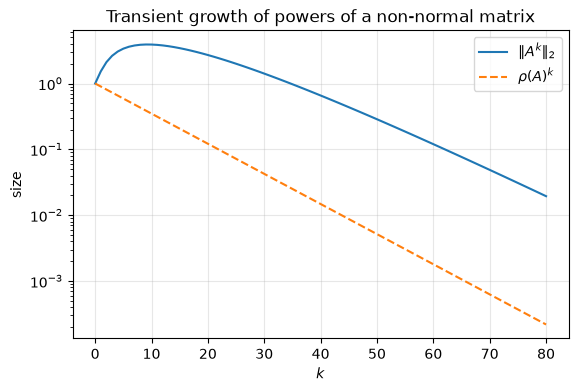

In [18]:
A = np.array([[0.9, 1.0], [0.0, 0.9]])
rho = np.max(np.abs(np.linalg.eigvals(A)))
ks = np.arange(0, 81)
norms = [np.linalg.norm(np.linalg.matrix_power(A, k), 2) for k in ks]
print(f"rho(A) = {rho}, ||A||_2 = {np.linalg.norm(A, 2):.4f}; max_k ||A^k||_2 = {max(norms):.3f} at k = {ks[np.argmax(norms)]}")

fig, ax = plt.subplots()
ax.semilogy(ks, norms, label=r"$\|A^k\|_2$")
ax.semilogy(ks, rho ** ks, "--", label=r"$\rho(A)^k$")
ax.set_xlabel("$k$")
ax.set_ylabel("size")
ax.set_title("Transient growth of powers of a non-normal matrix")
ax.legend()
plt.show()
assert all(rho ** k <= nk * (1 + 1e-12) for k, nk in zip(ks, norms))   # 1e-12 >> O(k u) rounding in A^k

## 9. Estimating $\|A\|_2$ by sampling

Every unit vector gives a lower bound $\|Ax\|_2\le\|A\|_2$. Sampling random
directions is therefore a natural but poor estimator, especially in high
dimension ([Exercise 1.11](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-ex-sampling)). One step of the power method,
$\|A^TAx\|_2/\|Ax\|_2$, is guaranteed to be at least as good as $\|Ax\|_2$.

n =  3: ||A||_2 = 2.9699, best sample = 2.9699, best after one power step = 2.9699
n = 50: ||A||_2 = 13.5384, best sample = 10.0755, best after one power step = 12.4466


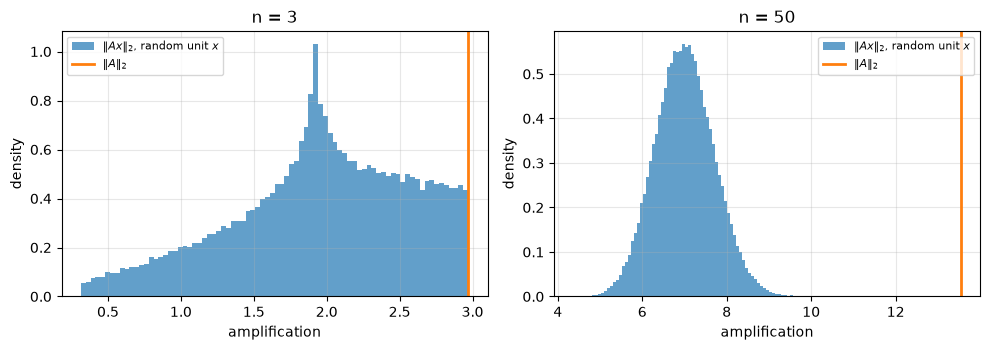

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, n in zip(axes, (3, 50)):
    A = rng.standard_normal((n, n))
    X = rng.standard_normal((n, 100_000))
    X /= np.linalg.norm(X, axis=0)
    AX = A @ X
    amp = np.linalg.norm(AX, axis=0)
    power = np.linalg.norm(A.T @ AX, axis=0) / amp
    sigma1 = np.linalg.norm(A, 2)
    ax.hist(amp, bins=80, density=True, alpha=0.7, label=r"$\|Ax\|_2$, random unit $x$")
    ax.axvline(sigma1, color="C1", lw=2, label=r"$\|A\|_2$")
    ax.set_xlabel("amplification")
    ax.set_ylabel("density")
    ax.set_title(f"n = {n}")
    ax.legend(fontsize=8)
    print(f"n = {n:2d}: ||A||_2 = {sigma1:.4f}, best sample = {amp.max():.4f}, "
          f"best after one power step = {power.max():.4f}")
    # 1e-12 >> O(n u), the rounding error of the computed norms
    assert amp.max() <= sigma1 * (1 + 1e-12) and np.all(power >= amp * (1 - 1e-12))
plt.tight_layout()
plt.show()

In three dimensions a hundred thousand samples come close to the maximum;
in fifty dimensions they do not, because a random direction is almost
orthogonal to the maximizing one. This is an early example of a theme of
[Chapter 12](https://aalsammani.github.io/numerical-linear-algebra/ch12-randomized/notes.html#ch12): random sampling works well only when it is
combined with the structure of the problem, here the power method.

## 10. Small norms, large condition number

We verify the numbers quoted in [Example 1.4](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-exa-hilbert).

In [20]:
H = sla.hilbert(10)
vals = {
    "||H||_1": np.linalg.norm(H, 1),
    "||H||_inf": np.linalg.norm(H, np.inf),
    "||H||_2": np.linalg.norm(H, 2),
    "||H||_F": np.linalg.norm(H, "fro"),
    "lambda_min": np.linalg.eigvalsh(H)[0],
    "kappa_2": np.linalg.cond(H),
}
for name, val in vals.items():
    print(f"{name:10s} = {val:.4g}")
assert abs(vals["||H||_1"] - sum(1 / j for j in range(1, 11))) < 1e-14
assert round(vals["||H||_2"], 3) == 1.752 and round(vals["||H||_F"], 3) == 1.786

||H||_1    = 2.929
||H||_inf  = 2.929
||H||_2    = 1.752
||H||_F    = 1.786
lambda_min = 1.093e-13
kappa_2    = 1.602e+13


The computed $\kappa_2(H_{10})\approx1.6\times10^{13}$ is itself subject to
rounding error of relative size roughly $\kappa_2 u\approx 10^{-3}$ in the
smallest eigenvalue, so only its first two or three digits are meaningful.
[Chapter 4](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04) explains why.

## Common mistakes

- Comparing two computed results with `==` or with a tolerance chosen by
  trial and error. Derive the tolerance from an error bound, as in Section 1.
- Timing a single run, or timing the first call (which includes one-time
  overheads), and reporting the result as a property of an algorithm.
- Forming a Householder matrix $H$ explicitly to apply it. Apply
  $y - \beta v(v^Ty)$ instead.
- Using $\sqrt{a^2+b^2}$ instead of `hypot` inside rotations and norms.
- Assuming $\|A\|_2 = \max_i|\lambda_i(A)|$ for a nonsymmetric matrix.
- Using `np.random.seed`; use a `Generator` from `np.random.default_rng`
  so that each notebook controls its own random stream.

## Your turn

1. Write `matmul_row(A, B)` that forms each *row* of $C$ as a combination of
   rows of $B$, and verify it with the bound of Section 1.
2. Extend `householder_vector` to complex vectors. What replaces the sign of
   $x_1$? (Use $x_1/|x_1|$.)
3. Show numerically that $\|A\|_2\le\sqrt{\|A\|_1\|A\|_\infty}$
   ([Exercise 1.4](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-ex-two-norm-bound)) for 1000 random matrices of various
   shapes. How tight is the bound typically?
4. Repeat the sampling experiment of Section 9 with $n = 10, 20, 100$ and
   plot the ratio of the best sample to $\|A\|_2$ against $n$.

## Key takeaways

- The inner-product, column and outer-product views of $AB$ are the same
  arithmetic in different orders; the latter two explain range, rank and
  low-rank structure.
- Flop counts are machine independent; run times are not, and must be
  measured carefully and reported as observations.
- Householder reflectors with the sign of [Algorithm 1.1](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-alg-householder) map
  a vector to a multiple of $e_1$ with errors of order $u$; the other sign
  suffers cancellation.
- Norm inequalities, unitary invariance and $\rho(A)\le\|A\|$ can all be
  checked numerically, and the checks should use tolerances derived from
  rounding error bounds.

## Further reading

Trefethen and Bau (1997), Lectures 1--3, and Golub and Van Loan (2013), Chapters 1
and 2. For the rounding error bound used in Section 1, see
Higham (2002), Section 3.5.